Do yesterday's QQQ returns help predict today's QQQ returns?

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

print("Working environment ready.")

Working environment ready.


In [13]:
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

figures_dir = project_root / "figures"
figures_dir.mkdir(exist_ok=True)

figures_dir

WindowsPath('c:/Users/jtsam/Coding/bayesian-times-series-finance/figures')

In [2]:
ticker = "QQQ"

qqq = yf.download(
    ticker,
    start="2015-01-01",
    auto_adjust=True,
    progress=False
)

prices = qqq[["Close"]].copy()
prices = prices.rename(columns={"Close": "QQQ_close"})

prices["QQQ_log_return"] = np.log(
    prices["QQQ_close"] / prices["QQQ_close"].shift(1)
)

returns = prices["QQQ_log_return"].dropna()

returns.head()

Date
2015-01-05   -0.014777
2015-01-06   -0.013499
2015-01-07    0.012809
2015-01-08    0.018959
2015-01-09   -0.006605
Name: QQQ_log_return, dtype: float64

Import relevant machine-learning libraries.

In [3]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

Create lagged returns.

In [4]:
ar_data = pd.DataFrame({
    "return_t": returns,
    "return_lag_1": returns.shift(1)
}).dropna()

ar_data.head()

,return_t,return_lag_1
Date,,
2015-01-06,-0.013499,-0.014777
2015-01-07,0.012809,-0.013499
2015-01-08,0.018959,0.012809
2015-01-09,-0.006605,0.018959
2015-01-12,-0.010482,-0.006605


Split into train and test sets.

In [5]:
split_index = int(len(ar_data) * 0.8)

train = ar_data.iloc[:split_index]
test = ar_data.iloc[split_index:]

print(f"Training set size: {len(train)}")
print(f"Test set size: {len(test)}")

print(f"Training set date range: {train.index.min().date()} to {train.index.max().date()}")
print(f"Test set date range: {test.index.min().date()} to {test.index.max().date()}")

Training set size: 2300
Test set size: 575
Training set date range: 2015-01-06 to 2024-02-26
Test set date range: 2024-02-27 to 2026-06-11


The AR(1) model is trained on the first 80% of the return data and evaluated on the final 20%. Since this is time-series
data, the split is chronological rather than random. This better reflects a realistic forecast setting where only past
information is available when predicting future returns.

An AR(1) model is: r_t = c + φ r_{t-1} + ε_t

In [6]:
y_train = train["return_t"]
X_train = train[["return_lag_1"]]

X_train = sm.add_constant(X_train, has_constant="add")

ar1_model = sm.OLS(y_train, X_train).fit()

print(ar1_model.summary())

                            OLS Regression Results                            
Dep. Variable:               return_t   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     29.04
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           7.82e-08
Time:                        21:38:57   Log-Likelihood:                 6573.7
No. Observations:                2300   AIC:                        -1.314e+04
Df Residuals:                    2298   BIC:                        -1.313e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0007      0.000      2.550   

Extract key information.

In [7]:
c_hat = ar1_model.params["const"]
phi_hat = ar1_model.params["return_lag_1"]
p_value = ar1_model.pvalues["return_lag_1"]
r_squared = ar1_model.rsquared

print(f"Estimated constant (c): {c_hat:.8f}")
print(f"Estimated AR(1) coefficient (φ): {phi_hat:.8f}")
print(f"P-value for AR(1) coefficient: {p_value:.6f}")
print(f"Training R-squared: {r_squared:.6f}")

Estimated constant (c): 0.00073934
Estimated AR(1) coefficient (φ): -0.11167936
P-value for AR(1) coefficient: 0.000000
Training R-squared: 0.012479


The AR(1) coefficient measures whether yesterday's return has linear predictive power for today's return. If this
coefficient is close to zero, then yesterday's QQQ return provides little information about today's return. The R-squared value
measures how much variation in daily returns is explained by the model. 

Below ar1_prediction is the prediction on the test set from yesterday's returns. mean_prediction is a simple baseline prediction using the average training return.

In [8]:
y_test = test["return_t"]
X_test = test[["return_lag_1"]]

X_test = sm.add_constant(X_test, has_constant="add")

test["ar1_prediction"] = ar1_model.predict(X_test)
test["mean_prediction"] = y_train.mean()

test.head()

,return_t,return_lag_1,ar1_prediction,mean_prediction
Date,,,,
2024-02-27,0.002402,-0.000527,0.000798,0.000666
2024-02-28,-0.005339,0.002402,0.000471,0.000666
2024-02-29,0.008533,-0.005339,0.001336,0.000666
2024-03-01,0.014945,0.008533,-0.000214,0.000666
2024-03-04,-0.003575,0.014945,-0.000930,0.000666


Plot actual test returns against AR(1) predictions.

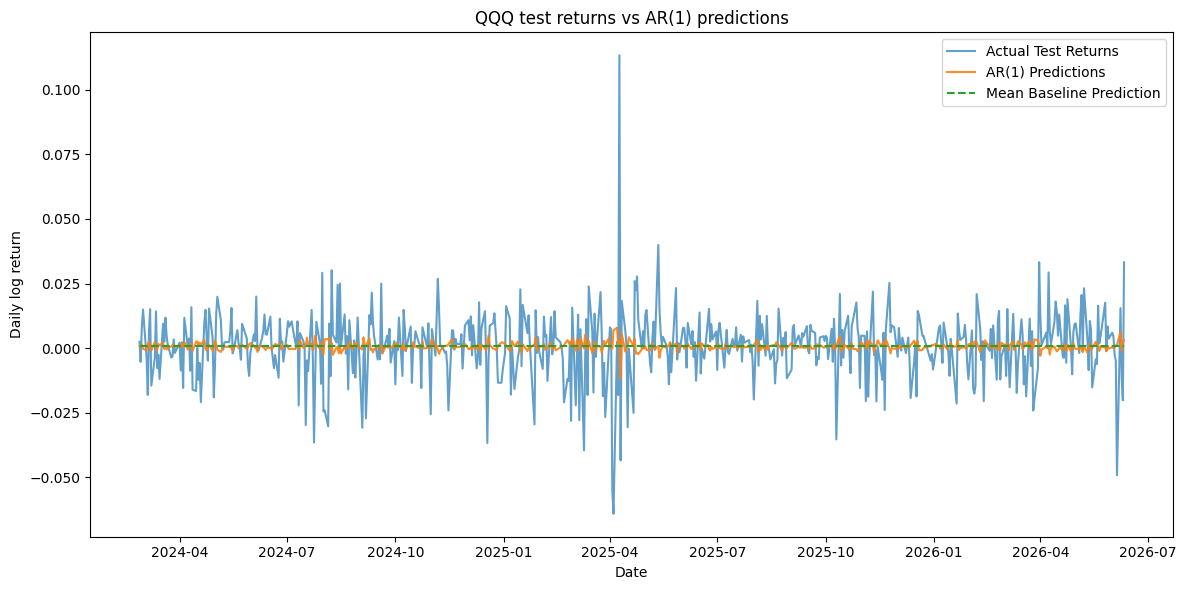

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    test.index,
    test["return_t"],
    label="Actual Test Returns",
    alpha=0.7,
)

ax.plot(
    test.index,
    test["ar1_prediction"],
    label="AR(1) Predictions",
    alpha=0.9,
)

ax.plot(
    test.index,
    test["mean_prediction"],
    label="Mean Baseline Prediction",
    linestyle="--"
)

ax.set_title("QQQ test returns vs AR(1) predictions")
ax.set_xlabel("Date")
ax.set_ylabel("Daily log return")
ax.legend()

plt.tight_layout()
plt.savefig(figures_dir / "qqq_ar1_predictions.png", dpi=300, bbox_inches='tight')
plt.show()

The AR(1) predictions remain close to zero and do not track the large positive or negative returns well. This suggests that yesterday's return alone has limited ability to forecast the magnitude or direction of future QQQ daily returns.

Compare AR(1) predictions errors to mean baseline errors.

In [10]:
ar1_errors = test["return_t"] - test["ar1_prediction"]
mean_errors = test["return_t"] - test["mean_prediction"]

ar1_mse = np.mean(ar1_errors ** 2)
mean_mse = np.mean(mean_errors ** 2)

ar1_mae = np.mean(np.abs(ar1_errors))
mean_mae = np.mean(np.abs(mean_errors))

print(f"AR(1) Test MSE: {ar1_mse:.10f}")
print(f"Mean Baseline Test MSE: {mean_mse:.10f}")

print(f"AR(1) Test MAE: {ar1_mae:.10f}")
print(f"Mean Baseline Test MAE: {mean_mae:.10f}")

AR(1) Test MSE: 0.0001731695
Mean Baseline Test MSE: 0.0001738922
AR(1) Test MAE: 0.0091594576
Mean Baseline Test MAE: 0.0091207797


Calculate percentage improvement.

In [11]:
mse_improvement = (mean_mse - ar1_mse) / mean_mse
mae_improvement = (mean_mae - ar1_mae) / mean_mae

print(f"MSE improvement over mean baseline: {mse_improvement:.2%}")
print(f"MAE improvement over mean baseline: {mae_improvement:.2%}")

MSE improvement over mean baseline: 0.42%
MAE improvement over mean baseline: -0.42%


The AR(1) model is compared against a simple baseline that always predicts the average return from the training set. If the 
AR(1) model only produces a very small improvement, or performs worse than the mean baseline, this indicates that lagged daily returns contains little useful predictive information for QQQ daily returns.

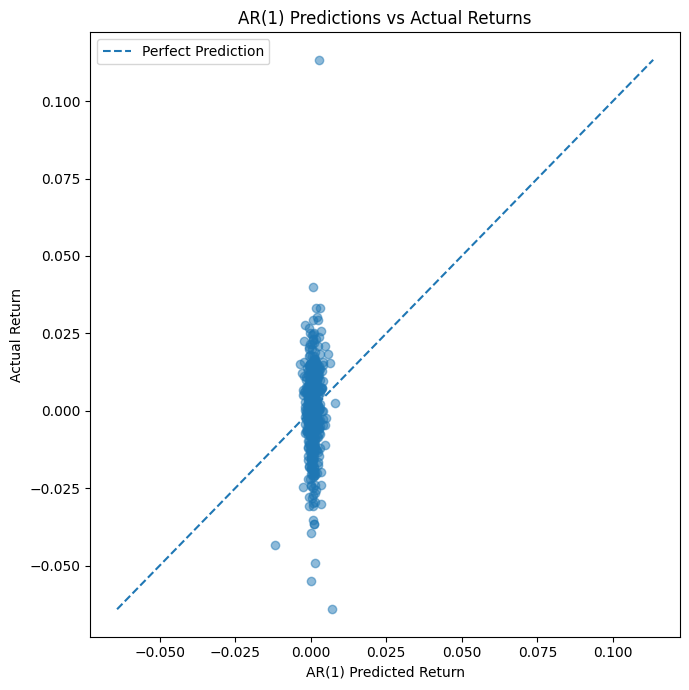

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    test["ar1_prediction"],
    test["return_t"],
    alpha=0.5,
)

min_value = min(test["ar1_prediction"].min(), test["return_t"].min())
max_value = max(test["ar1_prediction"].max(), test["return_t"].max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

ax.set_title("AR(1) Predictions vs Actual Returns")
ax.set_xlabel("AR(1) Predicted Return")
ax.set_ylabel("Actual Return")
ax.legend()

plt.tight_layout()
plt.savefig(figures_dir / "qqq_ar1_scatter_actual_returns.png", dpi=300, bbox_inches='tight')
plt.show()

The scatter plot compares predicted returns with actual returns. If AR(1) had strong predictive power, the points would cluster around the diagonal line. Instead, the predictions are concentrated near zero while actual returns vary much more widely, showing the model does not capture most daily return movements.

This section is on why return prediction is hard.

The AR(1) model tests whether yesterday's QQQ return has linear predictive power for today's return. In this notebook, the model is trained on the first 80% of the data, and evaluated on the final 20%, so the test results reflect out-of-sample predictive performance.

The estimated AR(1) coefficient is expected to be small, and the model's predictions remain close to the average return. This means that yesterday's return does not explain much of the variation in today's return. In the test set, the AR(1) model may only slightly improve on a simple mean-return baseline, or may fail to improve on it at all.

This reflects a broader problem in financial return prediction. Liquid assets, such as QQQ, are widely traded, so simple return patterns are likely to be quickly exploited and removed. Daily returns are also strongly affected by new information, macroeconomic news, earnings expectations, risk sentiment, and market-wide shocks, most of which cannot be predicted from yesterday's return alone.

However, this does not mean that financial time series have no structure. The previous notebook showed evidence of heavy tails and volatility clustering, where large moves tend to occur near other large moves. Since the AR(1) model only captures linear dependence in raw returns, a natural next step is first to replace the Gaussian error assumption with a heavier-tailed Student-t likelihood. After this, the project can move towards explicit volatility modelling using rolling volatility, GARCH-type models, and ultimately Bayesian stochastic volatility models.